<a href="https://colab.research.google.com/github/drobertsonmba/alfred-autonomous-orchestrator/blob/main/GitHub_Masterfile_Alfred_Code_Agent_70B_dr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

##Project Summary: Alfred - The 70B High-Fidelity Migration
**Objective**: I transitioned the Alfred orchestrator to the 70B engine to handle high-complexity reasoning tasks while operating under a strict 100K TPD limit. My goal was to prove that I could generate high-fidelity mission assets without triggering infrastructure failure.

**The Mission (Deliverables)**:

![Alfred v14 Identity Block](https://github.com/drobertsonmba/alfred-autonomous-orchestrator/blob/main/assets/alfred_v14_identity.png?raw=true)

I tasked the Alfred v14 (70B) agent with orchestrating a "Villain Gala" requiring four specific, themed outputs:

*   **Mission Theme**: A cohesive narrative framework: "In a world where chaos reigns, villains unite to unleash their darkest schemes."

*   **Logistics Calculation**: A precise prep-time estimate for 150 guests (calculated at 37.5 hours).

*   **Historical Playlist**: A 5-track playlist spanning from the 1960s to the present, curated to fit the dark aesthetic (e.g., The Hills by The Weeknd, Bad Guy by Billie Eilish).

*   **Themed Menu**: A three-course meal featuring character-themed ingredients, which Alfred recommended dishes such as "Joker's Wild" crab and "Penguin's Perfect Dish" lobster.



##Tactics: Executing the 70B Strategy
To achieve these deliverables while maintaining Auditability, I employed the following tactics:

**Zone 0 Provisioning**: I built an armored chassis with a graphical progress tracker to ensure all 9 governance layers (including Langfuse and OpenTelemetry) were nominal before the mission began.

**Active Token Governance**: I utilized a TokenAwareGovernor to proactively gate requests. I set a 9,600 TPM ceiling to manage the Groq LPU pressure and ensure I stayed within my 11% safety buffer.

**Unified Automated Handshake**: I leveraged the Langfuse SDK v2+ upgrade to consolidate my telemetry into a single, high-fidelity pipe, removing the redundant manual "pings" used in the [8B](https://github.com/drobertsonmba/alfred-autonomous-orchestrator/blob/main/8B_Alfred_Code_Agent_dr.ipynb) version.

##70B Resiliency Audit

**Audit ID**: `c740f03e30f1e5f4 `| **Status**: 🟢 NOMINAL

I verified the success of my tactics by reconciling the mission logs against my Infrastructure-First standards:

**TPM Pressure**: Peak utilized was 28.1% of my ceiling.

**TPD Remaining**: 97,302 / 100,000 tokens.

**Fidelity**: The agent successfully executed all four deliverables in a single pass.


## 🛠️ The Tech Stack:

* **Engine:** `Llama-3.3-70B-versatile` (via Groq LPU)
    * **Role:** High-fidelity reasoning for complex, multi-variable tasks (Logistics, Chronological Playlists, and Thematic Menus).

<br>

* **Orchestration:** `smolagents` (**Alfred v14 Framework**)
    * **Role:** Managing the `CodeAgent` and `ToolCalling` logic that connects the 70B engine to our infrastructure.

<br>

* **Observability:** `Langfuse SDK v2+` (Chain-of-Thought & Financial Auditing)
    * **Role:** Providing Unified Automated Path telemetry to anchor every mission trace with forensic precision.

<br>

* **Governance:** `ForensicGovernor` (Active Pre-Flight Gating)
    * **Role:** Custom Python function to enforce a **9,600 TPM Ceiling** and manage the **100K TPD bottleneck** to maintain our **11% Safety Buffer**.

### Alfred Migration Delta: v13 ([8B](https://github.com/drobertsonmba/alfred-autonomous-orchestrator/blob/main/8B_Alfred_Code_Agent_dr.ipynb)) → v14 (70B)

| Feature | Alfred v13 (8B Notebook) | Alfred v14 (70B Graduate) | Forensic Impact |
| :--- | :--- | :--- | :--- |
| **Core Engine** | llama-3.1-8b-instant | Llama-3.3-70B-versatile | 70B handles high-fidelity creative logic. |
| **TPD Constraint** | 500,000 | **100,000 (Critical Limit)** | 80% reduction in daily token liquidity. |
| **TPM Ceiling** | 4,800 (20% buffer) | **9,600 (11% buffer)** | Tightened governance for 70B LPU speeds. |
| **Telemetry** | Dual-Path Automated | **Unified Automated** | Single source of truth for all mission traces. |
| **Rate Limiting** | Passive (Reactive) | **Active (Proactive)** | Prevents 429s before the API is called. |
| **Governance Mode** | Forensic Logging | **ForensicGovernor()** | Pre-flight gating & weighted pressure logic. |

In [ ]:
# ZONE 0: THE FOUNDATION
# HF released transformer v5 on 12/1/25, requiring HF-hub 1.3.0
# (the librarian that allows system to check-out model and Metadata/Tokenizer),
# which is sent to the transformers libray for the counting. Note: Since we're using Groq,
# it actually provides the model and transformer overlay with its LPU engine, so I don't import transformers package.
import sys, time

# Python loop to create an Installation Resiliency Progress Bar Tracker
def progress_bar(current, total, bar_length=20):
    fraction = current / total
    arrow = int(fraction * bar_length - 1) * '=' + '>'
    padding = int(bar_length - len(arrow)) * ' '
    ending = '\n' if current == total else '\r'
    print(f'🛠️ Hardening: [{arrow}{padding}] {int(fraction*100)}% ({current}/{total} Layers)', end=ending)

# 1. Provisioning the chassis for Alfred v14 (70B) Resiliency
try:
    import langfuse, litellm, smolagents, groq, pytz # Using smolagents as orchestrator for API calls.
    from openinference.instrumentation.smolagents import SmolagentsInstrumentor
    print("✅ Infrastructure: Resiliency Chassis already present.")
except ImportError:
    # 2. 🛠️ HARDENING LOOP (Progress Tracker)
    print("🚀 Initializing Provisioning for 100K TPD bottleneck...")
    libraries = [
        "groq", "smolagents", "langfuse", "litellm",
        "python-dotenv", "pandas", "openinference-instrumentation-smolagents",
        "opentelemetry-sdk", "opentelemetry-exporter-otlp"
    ]

    total = len(libraries)
    for i, lib in enumerate(libraries, 1):
        # Graphical Progress Bar
        fraction = i / total
        arrow = int(fraction * 20 - 1) * '=' + '>'
        padding = int(20 - len(arrow)) * ' '
        print(f'\r🛠️ Hardening: [{arrow}{padding}] {int(fraction*100)}% ({i}/{total})', end='')

        # 2. Surgical Provisioning: Only what we need for the 70B LPU Overlay; avoids 'torch' ghost
        # -U (Short for --upgrade)
        # We explicitly exclude transformers/accelerate to prevent circular imports
        !pip install -q -U --no-cache-dir {lib}

    import site
    from importlib import reload
    reload(site)
    print("✅ Infrastructure: Path Refreshed & Lean.")

# 🛡️ PHASE 3: Forensic Sanity Check
try:
    import langfuse, litellm, smolagents
    from openinference.instrumentation.smolagents import SmolagentsInstrumentor

    print("✅ RESILIENCY VERIFIED: Local Transformers bypassed for Groq LPU.")

    # Defensive Version Fetching
    lf_v = getattr(langfuse, "__version__", "Active (SDK v2+)")
    lt_v = getattr(litellm, "__version__", "Active")
    sm_v = getattr(smolagents, "__version__", "Active")

    print(f"📊 Control Stack: Langfuse {lf_v} | LiteLLM {lt_v} | smolagents {sm_v}")
    print("🛡️ Infrastructure Status: NOMINAL")

except Exception as e:
    print(f"❌ INFRASTRUCTURE CRASH: Dependency conflict is functional. Error: {e}")
    sys.exit("Stopping: Infrastructure unstable. Check Zone 0 logs.")

🚀 Initializing Provisioning for 100K TPD bottleneck...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 10.3 MB/s eta 0:00:00
🛠️ Hardening: [===================>] 100% (9/9)✅ Infrastructure: Path Refreshed & Lean.
✅ RESILIENCY VERIFIED: Local Transformers bypassed for Groq LPU.
📊 Control Stack: Langfuse Active (SDK v2+) | LiteLLM Active | smolagents 1.24.0
🛡️ Infrastructure Status: NOMINAL


If a `grpcio` version warning appears, it is a **non-blocking dependency conflict** that is common in the Google Colab's pre-installed environment. It occurs because `grpcio-status` (a utility library) prefers a newer version than the one required by my core engine, litellm. Since my agent doesn't utilize the specific features of the 'status' library, this version mismatch does not impact the agent's performance or reasoning

In [ ]:
# ZONE 1: THE VAULT - GOVERNANCE & AUTHENTICATION
import os, base64, logging, sys, time, pytz
from datetime import datetime
from google.colab import userdata
from langfuse import Langfuse, get_client, propagate_attributes
from openinference.instrumentation.smolagents import SmolagentsInstrumentor

# 1. NOISE SUPPRESSION
logging.getLogger("opentelemetry.instrumentation.instrumentor").setLevel(logging.ERROR)

# 2. 🛡️ GOVERNANCE CEILINGS (Alfred v14 Focus)
tpm_limit = 12000     # 70B Rate Limit
TPM_CEILING = 9600      # 80% Safety Ceiling
tpd_limit = 100000    # 100K TPD Bottleneck
MAX_TOKENS_PER_RUN = 15000 # 11% Buffer for 6 runs

# 3. 💰 FISCAL AUDITING: 2026-03-04 Pricing (Per 1M Tokens)
MODEL_PRICING = {
    "llama-3.1-8b-instant": {"input": 0.05, "output": 0.08},
    "llama-3.3-70b-versatile": {"input": 0.59, "output": 0.79},
    "default": {"input": 0.10, "output": 0.10}
}

# 4. 🛰️ MISSION METADATA & CLOCK
eastern = pytz.timezone('US/Eastern')
TIMESTAMP_EST = datetime.now(eastern).strftime('%Y-%m-%d %H:%M:%S')
SESSION_ID = f"alfred-v14-{time.strftime('%m%d-%H%M')}"

# 5. 🔑 VAULT INITIALIZATION
def initialize_vault():
    for key in ["GROQ_API_KEY", "LANGFUSE_PUBLIC_KEY", "LANGFUSE_SECRET_KEY"]:
        os.environ[key] = userdata.get(key)
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com"

initialize_vault()
# 🛰️ THE SDK INSTANCE (The "Steering Wheel" with .score method)
langfuse_sdk = Langfuse(
    public_key=os.environ["LANGFUSE_PUBLIC_KEY"],
    secret_key=os.environ["LANGFUSE_SECRET_KEY"],
    host=os.environ["LANGFUSE_HOST"]
)

# 🛰️ THE BACKGROUND CLIENT (The "Observer" for smolagents)
# We rename this to 'otel_client' to prevent shadowing our SDK instance
otel_client = get_client()

# --- 📡 THE LANGFUSE LIFE SIGNAL CHECK ---
try:
    if langfuse_sdk.auth_check():
        print("✅ INFRASTRUCTURE ARMORED: langfuse_sdk is live.")
except Exception as e:
    print(f"❌ AUTH FAILURE: {e}")

# 6. 📡 TELEMETRY HANDSHAKE (OTEL)
auth_str = f"{os.environ['LANGFUSE_PUBLIC_KEY']}:{os.environ['LANGFUSE_SECRET_KEY']}"
encoded_auth = base64.b64encode(auth_str.encode()).decode()
os.environ.update({
    "OTEL_EXPORTER_OTLP_ENDPOINT": f"{os.environ['LANGFUSE_HOST']}/api/public/otel",
    "OTEL_EXPORTER_OTLP_HEADERS": f"Authorization=Basic {encoded_auth}"
})

# Re-instrumenting the observer
try: SmolagentsInstrumentor().uninstrument()
except: pass
SmolagentsInstrumentor().instrument()

print("🚀 VAULT VERIFIED: Audit (SDK) & Trace (Client) paths established for 70B.")
print(f"🕒 CLOCK: {TIMESTAMP_EST} | ⛽ TPD BUDGET: 100K (Max {MAX_TOKENS_PER_RUN}/run)")

# GLOBAL RE-ARMORING: Variable Sanitization
# Run this once to clean the notebook environment
if 'TPD_LIMIT_I' in globals():
    TPD_LIMIT = TPD_LIMIT_I
    print("🧹 Cleaned: TPD_LIMIT_I migrated to TPD_LIMIT.")

# Define these locally to ensure the cell runs, matching values from Zone 1 (kSPMMitpVyXe)
TPM_CEILING = 9600      # 80% Safety Ceiling from Zone 1
TPD_LIMIT = 100000    # 100K TPD Bottleneck from Zone 1

# Ensure lowercase versions exist for the Governor/Zone 5
tpm_limit = TPM_CEILING
tpd_limit = TPD_LIMIT
print(f"✅ Governance Standardized: tpm_limit={tpm_limit}, tpd_limit={tpd_limit}")

✅ INFRASTRUCTURE ARMORED: langfuse_sdk is live.
🚀 VAULT VERIFIED: Audit (SDK) & Trace (Client) paths established for 70B.
🕒 CLOCK: 2026-03-06 10:14:50 | ⛽ TPD BUDGET: 100K (Max 15000/run)
✅ Governance Standardized: tpm_limit=9600, tpd_limit=100000


In [ ]:
# ZONE 1.5: THE VALIDITY PROBE (Infrastructure Health Check)
import os
from langfuse import Langfuse
import litellm

# 1. 🛡️ Credentials Check
# Ensures our Vault Injection from Zone 1 actually "stuck"
required_keys = ["GROQ_API_KEY", "LANGFUSE_PUBLIC_KEY", "LANGFUSE_SECRET_KEY"]
for key in required_keys:
    if not os.getenv(key):
        raise ValueError(f"❌ Infrastructure Failure: {key} is missing.")

# 2. 🛰️ Langfuse Probe (Auditability Check)
# Verifies the 30-day Warm Storage access we confirmed earlier
if not langfuse_sdk.auth_check():
    raise RuntimeError("❌ Langfuse Auth Failed: Keys invalid.")
print("✅ Langfuse: Authenticated & Ready for 70B Auditing.")

# 3. 🚀 Groq Engine Probe (LPU Connectivity Health Probe)
try:
    # 🕵️ Forensic Pulse: We perform a 1-token handshake.
    # This verifies the Tokenizer (Zone 0) and the API Key (Zone 1) in one shot.
    litellm.completion(
        model="groq/llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": "health_check_ping"}],
        max_tokens=1,
        timeout=10 # Defensive Engineering: don't let a jittery LPU hang the notebook
    )
    print("✅ Groq: Engine Ready (llama-3.3-70b-versatile).")
    print("⚓ Registry: Engine anchored for Graduate-Level missions.")
except Exception as e:
    # Captures the "Smoking Gun" if the connection is refused
    raise RuntimeError(f"❌ Groq Connection Failed: {e}")

print(f"\n🚀 INFRASTRUCTURE VALIDATED: Ready for Alfred v14 (70B) v2.")

✅ Langfuse: Authenticated & Ready for 70B Auditing.
✅ Groq: Engine Ready (llama-3.3-70b-versatile).
⚓ Registry: Engine anchored for Graduate-Level missions.

🚀 INFRASTRUCTURE VALIDATED: Ready for Alfred v14 (70B) v2.


The warning `Attempting to uninstrument while already uninstrumented` is a byproduct of an **Idempotent Reset Pattern**. By calling `.uninstrument()` before `.instrument()`, I ensure a *clean slate* for the telemetry bridge. This prevents duplicate instrumentation layers (which could cause double-counting of tokens or metrics) if the cell is re-run during development. The warning simply confirms the system was already clean, which is the desired starting state for a reliable monitoring loop.

In [ ]:
# ZONE 2. THE BRAIN: MODEL CONFIGURATION & RESOURCE GUARDRAILS
from smolagents import LiteLLMModel

# 1. 🚀 Alfred v14 (70B) Graduate Engine
model = LiteLLMModel(
    model_id="groq/llama-3.3-70b-versatile", # Updated for v14
    api_base="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"],
    requests_per_minute=30,
    max_tokens=MAX_TOKENS_PER_RUN, # Physical 15K Token Guardrail
    temperature=0.2               # Lower for Full Retention/Auditability
)

# 2. 🕵️ INFRASTRUCTURE AUDIT: LAYER & THROUGHPUT VERIFICATION
print("\n" + "="*100)
print(f"🔍 ENGINE: {model.model_id} (Alfred v14)")
print(f"🔍 ARCHITECTURE: 70B Llama-3.3 Stack (High Density Reasoning)")
print(f"🔍 THROUGHPUT: 9,600 TPM Ceiling | 100K TPD Bottleneck")
print(f"🔍 OBSERVABILITY: Active Langfuse Trace / gRPC Instrumentation")
print("="*100)

# 🚀 HEARTBEAT ADDITION: FISCAL AUDIT (2026-03-01 PRICING)
def run_fiscal_heartbeat():
    # Simulated 100-token test run
    test_input, test_output = 50, 50
    # Logic: Using the 70B pricing from MODEL_PRICING in Zone 1
    pricing = MODEL_PRICING.get("llama-3.3-70b-versatile", MODEL_PRICING["default"])

    cost = (test_input / 1_000_000 * pricing["input"]) + \
           (test_output / 1_000_000 * pricing["output"])

    print(f"--- 💓 FISCAL HEARTBEAT ---")
    print(f"MODEL: Alfred v14 (70B) | TEST VOL: 100 Tokens")
    print(f"CALCULATED COST: ${cost:8f}")
    print(f"PRICING VERIFIED: {'✅' if cost > 0 else '❌'}")

run_fiscal_heartbeat()

# 3. DEFENSIVE ENGINEERING: CIRCUIT BREAKER
stop_after_audit = False
if stop_after_audit:
    sys.exit("🛑 CIRCUIT BREAKER ACTIVE: Set 'stop_after_audit = False' to continue.")

print(f"✅ Command Center Online: {model.model_id} is governed at 15K tokens per mission.")


🔍 ENGINE: groq/llama-3.3-70b-versatile (Alfred v14)
🔍 ARCHITECTURE: 70B Llama-3.3 Stack (High Density Reasoning)
🔍 THROUGHPUT: 9,600 TPM Ceiling | 100K TPD Bottleneck
🔍 OBSERVABILITY: Active Langfuse Trace / gRPC Instrumentation
--- 💓 FISCAL HEARTBEAT ---
MODEL: Alfred v14 (70B) | TEST VOL: 100 Tokens
CALCULATED COST: $0.000069
PRICING VERIFIED: ✅
✅ Command Center Online: groq/llama-3.3-70b-versatile is governed at 15K tokens per mission.


In [ ]:
# ZONE 3: THE SKILLSET & THE GOVERNOR (Alfred v14 Armored)
import sys, collections, random, time, re, os
from typing import Any, List

# --- BEGIN PATCH FOR ModuleNotFoundError: smolagents ---
try:
    from smolagents import CodeAgent, Tool, tool, LiteLLMModel
except ImportError:
    print("⚠️ Missing 'smolagents' module. Attempting to install...")
    !pip install -q -U smolagents
    from smolagents import CodeAgent, Tool, tool, LiteLLMModel
    print("✅ 'smolagents' installed and imported.")
# --- END PATCH ---

# 1. ⚓ TELEMETRY STATE & GATEKEEPER
captured_trace_id = "Auto-Instrumented"
telemetry_warned = False

def log_audit_event(name, metadata):
    global captured_trace_id, telemetry_warned
    try:
        # 🕵️ DEFENSIVE CHECK: Using getattr for SDK flexibility
        if hasattr(langfuse_sdk, 'trace'):
            trace = langfuse_sdk.trace(
                name=f"Alfred-v14-{name}",
                tags=["70B-Graduate", "100K-TPD-Constraint"],
                metadata=metadata
            )
            captured_trace_id = trace.id
            print(f"📡 Telemetry: '{name}' linked to Langfuse Trace: {captured_trace_id}")
            return trace
        else:
            if not telemetry_warned:
                print(f"⚠️ Telemetry Bypass: Object has no '.trace'. Using Auto-Instrumentation.")
                telemetry_warned = True
            return None
    except Exception as e:
        print(f"⚠️ Telemetry Jitter: {e}")
        return None

# 2. ⚖️ THE GRADUATE GOVERNOR
class TokenAwareGovernor:
    def __init__(self, tpm_limit=9600, tpd_limit=100000):
        self.tpm_limit = tpm_limit
        self.tpd_limit = tpd_limit
        self.usage_history = collections.deque()
        self.daily_total = 0

    def _slide_window(self):
        now = time.time()
        while self.usage_history and now - self.usage_history[0][0] > 60:
            self.usage_history.popleft()

    def get_current_tpm(self):
        self._slide_window()
        return sum(tokens for _, tokens in self.usage_history)

    def pre_flight_clearance(self, prompt):
        self._slide_window()
        current_usage = self.get_current_tpm()
        # High-density estimation for 70B heavy reasoning
        estimated = 3000 + int(len(prompt.split()) * 4.0)

        if (current_usage + estimated) > self.tpm_limit:
            wait_needed = 60 - (time.time() - self.usage_history[0][0]) + 0.5
            print(f"⏳ TPM Congestion: Waiting {wait_needed:.1f}s to respect 9,600 Ceiling...")
            time.sleep(max(0, wait_needed))
            return self.pre_flight_clearance(prompt)

        if (self.daily_total + estimated) > self.tpd_limit:
            print(f"🚨 TPD EXHAUSTED: Budget {self.daily_total}/{self.tpd_limit}. Aborting.")
            return None

        self.usage_history.append((time.time(), estimated))
        self.daily_total += estimated
        print(f"✅ Clearance: {current_usage + estimated}/{self.tpm_limit} TPM | TPD: {self.daily_total/1000:.1f}K/100K")
        return estimated

# Initialize Governor with 2026 constraints [cite: 2026-03-01]
governor = TokenAwareGovernor(tpm_limit=TPM_CEILING, tpd_limit=tpd_limit)

# 3. 🛠️ TOOLS
@tool
def calculate_prep_time(GUEST_COUNT: int, MISSION_COMPLEXITY: str="high") -> str:
    """Calculates preparation hours based on guest count and complexity.

    Args:
        GUEST_COUNT (int): The number of guests attending the event.
        MISSION_COMPLEXITY (str): The level of effort required, either "high" or "low".
    """
    base_rate = 0.25 if MISSION_COMPLEXITY == "high" else 0.15
    total_hours = (GUEST_COUNT * base_rate)
    return f"Logistics Update: Total preparation for {GUEST_COUNT} guests is {total_hours:.1f} hours."

# 4. 🏁 AGENT STEERING
model = LiteLLMModel(
    model_id="groq/llama-3.3-70b-versatile",
    api_base="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"],
    requests_per_minute=30,
    max_tokens=15000, # 11% buffer for 6 successful runs/day [cite: 2026-03-04]
    temperature=0.2
)

agent = CodeAgent(
    tools=[calculate_prep_time],
    model=model,
    max_steps=5,
    additional_authorized_imports=["datetime", "re", "random", "typing"]
)

# SINGLE MISSION INITIALIZATION
log_audit_event("Mission-Init", {"agent": "Alfred-v14", "TPM_CEILING": TPM_CEILING})
print(f"✅ INFRASTRUCTURE STEERING: Alfred v14 online (9,600 TPM / 15K Run-Limit).")

⚠️ Telemetry Bypass: Object has no '.trace'. Using Auto-Instrumentation.
✅ INFRASTRUCTURE STEERING: Alfred v14 online (9,600 TPM / 15K Run-Limit).


In [ ]:
# ZONE 4: DYNAMIC MISSION CONTROL (Alfred v14 High Fidelity Execution)
# Initialize variables to be accessible globally after execution
input_tokens = 0
output_tokens = 0
actual_total = 0
execution_duration = 0.0
tps = 0.0
attempt = 0
captured_trace_id = None
final_report = ""
passed_validation = False

# 1. 🛡️ MISSION PREP & DYNAMIC ALIGNMENT
MISSION_COMPLEXITY = "high"  # Dynamic Steering: "low" | "high"
GUEST_COUNT = 150

print(f"⚙️ Aligning Engine for {MISSION_COMPLEXITY.upper()} Complexity Reasoning...")
agent.model.model_id = "groq/llama-3.3-70b-versatile"

# Defensive Engineering: Sanitize memory to ensure 15K token headroom
if hasattr(agent, 'memory'):
    agent.memory.steps = []
    print("🧹 Memory Sanitized: Context cleared for fresh 70B run.")

# 2. 🛰️ DYNAMIC MISSION PROMPT (v14 Version 2)
mission_prompt = f"""
Alfred, assume the role of Master Event Planner and execute the 'Villain Masquerade' plan.

CRITICAL INSTRUCTION: Execute all tool calls via Python code. BE CONCISE. Skip all
internal 'Thought' reasoning and do not summarize tool outputs. Provide only the final data report.
Target: 45-second SLA compliance.

REQUIREMENTS:
1. Prep Time: [Python Call: calculate_prep_time(GUEST_COUNT={GUEST_COUNT}, MISSION_COMPLEXITY='{MISSION_COMPLEXITY}')]
2. Theme: [One sharp, high-concept sentence reflecting {MISSION_COMPLEXITY} stakes]
3. Playlist: [5 tracks; Decade | Artist | Title | Style]
4. The 3-Course Menu that includes an appetizer, main course and dessert (NO REPEATED INGREDIENTS):
   - Provide a creative, descriptive name for each dish (e.g., "Two-Face's Grilled Filet Mignon)
   - Follow each name with: [3 unique ingredients].
   - Use distinct Villains for each course (Joker, Penguin, Poison Ivy).

DATA AUDIT: End with exactly this JSON: {{"Version": "Alfred-v14", "Status": "COMPLETED", "Complexity": "{MISSION_COMPLEXITY}"}}.
"""

# 3. 🛡️ CONSOLIDATED EXECUTION GATE
# a. 🛡️ PRE-FLIGHT DYNAMIC WEIGHTING
complexity_multiplier = 1.5 if MISSION_COMPLEXITY == "high" else 1.0
print(f"🔍 Requesting Governor Clearance ({complexity_multiplier}x Weight for {MISSION_COMPLEXITY})...")

# Calculate if we have room in our 100K TPD and 9,600 TPM ceiling
# We pass the multiplier to ensure the Governor waits long enough for a 'Heavy' 70B response
estimated_tokens = governor.pre_flight_clearance(mission_prompt)

if estimated_tokens:
    try:
        # 🛰️ TELEMETRY & ATTRIBUTE PROPAGATION
        with propagate_attributes(
            session_id = f"SESS-{int(time.time())}",
            tags=["Alfred-v14", MISSION_COMPLEXITY],
            metadata={
                "GUEST_COUNT": str(GUEST_COUNT),
                "MISSION_COMPLEXITY": MISSION_COMPLEXITY,
                "TPM_CEILING": "9600"
            }
        ):
            # Start the observation using the SDK Instance from Zone 1
            with langfuse_sdk.start_as_current_observation(name="Alfred_70B_Gala_v14") as observation:
                captured_trace_id = observation.id
                local_attempt, max_retries, local_passed_validation = 0, 3, False
                start_time = time.time()
                villain_keywords = ["joker", "lex", "vader", "maleficent", "riddler"] # Forensic check
                local_final_report = "" # Initialize local final report

                while local_attempt < max_retries and not local_passed_validation:
                    local_attempt += 1
                    print(f"🚀 Attempt {local_attempt} | ⛽ Budget Check: {governor.daily_total/1000:.1f}K/100K")

                    try:
                        # THE EXECUTION: Alfred v14 fires the 70B Engine
                        response_raw = agent.run(mission_prompt)
                        local_final_report = str(response_raw)

                        # VALIDATION: Ensuring 70B didn't hallucinate past the mission requirements
                        local_passed_validation = any(word.lower() in local_final_report.lower() for word in villain_keywords)

                        if not local_passed_validation:
                            print("⚠️ Validation Failed: Villain context missing. Retrying...")

                    except Exception as e:
                        # DEFENSIVE ENGINEERING: Forensic 429 Parsing
                        if "429" in str(e):
                            # Backoff logic to respect the 9,600 TPM ceiling jitter
                            wait_time = 30 # Default backoff or use governor.parse_429(str(e))
                            print(f"⏳ 429 Detected: Backing off {wait_time}s to clear 9,600 TPM...")
                            time.sleep(wait_time); local_attempt -= 1; continue
                        raise e

            # b. 📊 POST-FLIGHT TELEMETRY HARVESTING
            # Assign values to top-level variables
            execution_duration = time.time() - start_time

            # Fetching actuals from the agent monitor (Transformers v5 compatible)
            input_tokens = getattr(agent.monitor, 'total_input_token_count', 0)
            output_tokens = getattr(agent.monitor, 'total_output_token_count', 0)
            actual_total = input_tokens + output_tokens

            # RECONCILIATION: Update Governor with ACTUALS instead of ESTIMATES
            # We subtract the estimate we added in pre_flight and add the real truth
            governor.daily_total = (governor.daily_total - estimated_tokens) + actual_total

            tps = float(f"{actual_total / execution_duration:.2f}") if execution_duration > 0 else 0

            # Assign final values of attempt, final_report, passed_validation to top-level scope
            # Anchor to Global Scope
            attempt, final_report, passed_validation = local_attempt, local_final_report, local_passed_validation

            if passed_validation:
                print(f"🎯 SUCCESS | SLA: {execution_duration:.1f}s | TPS: {tps}")
                print(f"📊 Final Mission Cost: {actual_total} tokens")
                print(f"\n✅ MISSION COMPLETE ({MISSION_COMPLEXITY.upper()}): \n{final_report}")
            else:
                print("❌ Mission failed after max retries.")

    except Exception as e:
        print(f"❌ Infrastructure Failure: {e}")
else:
    print("🛑 MISSION ABORTED: Governor denied clearance for high-density request.")

⚙️ Aligning Engine for HIGH Complexity Reasoning...
🧹 Memory Sanitized: Context cleared for fresh 70B run.
🔍 Requesting Governor Clearance (1.5x Weight for high)...
✅ Clearance: 3540/9600 TPM | TPD: 3.5K/100K
🚀 Attempt 1 | ⛽ Budget Check: 3.5K/100K


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Alfred, assume the role of Master Event Planner and execute the 'Villain Masquerade' plan.                      │
│                                                                                                                 │
│ CRITICAL INSTRUCTION: Execute all tool calls via Python code. BE CONCISE. Skip all                              │
│ internal 'Thought' reasoning and do not summarize tool outputs. Provide only the final data report.             │
│ Target: 45-second SLA compliance.                                                                               │
│                                                                                                                 │
│ REQUIREMENTS:                                                                                                   │
│ 1. Prep Time: [Python Call: calculate_prep_time(GUEST_COUNT=150, MISSION_COMPLEXITY='high')\]                   │
│ 2. Theme: [One sharp, high-concept sentence reflecting high stakes\]                                            │
│ 3. Playlist: [5 tracks; Decade | Artist | Title | Style\]                                                       │
│ 4. The 3-Course Menu that includes an appetizer, main course and dessert (NO REPEATED INGREDIENTS):             │
│    - Provide a creative, descriptive name for each dish (e.g., "Two-Face's Grilled Filet Mignon)                │
│    - Follow each name with: [3 unique ingredients\].                                                            │
│    - Use distinct Villains for each course (Joker, Penguin, Poison Ivy).                                        │
│                                                                                                                 │
│ DATA AUDIT: End with exactly this JSON: {"Version": "Alfred-v14", "Status": "COMPLETED", "Complexity": "high"}. │
│                                                                                                                 │
╰─ LiteLLMModel - groq/llama-3.3-70b-versatile ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prep_time = calculate_prep_time(GUEST_COUNT=150, MISSION_COMPLEXITY='high')                                      
  print("Prep Time:", prep_time)                                                                                   
                                                                                                                   
  theme = "In a world where chaos reigns, villains unite to unleash their darkest schemes."                        
  print("Theme:", theme)                                                                                           
                                                                                                                   
  playlist = [                                                                                                     
      {"Decade": "80s", "Artist": "Michael Jackson", "Title": "Thriller", "Style": "Pop"},                         
      {"Decade": "90s", "Artist": "Nirvana", "Title": "Smells Like Teen Spirit", "Style": "Grunge"},               
      {"Decade": "2000s", "Artist": "Lady Gaga", "Title": "Poker Face", "Style": "Electro Pop"},                   
      {"Decade": "2010s", "Artist": "The Weeknd", "Title": "The Hills", "Style": "Dark R&B"},                      
      {"Decade": "2020s", "Artist": "Billie Eilish", "Title": "Bad Guy", "Style": "Electro Pop"}                   
  ]                                                                                                                
  print("Playlist:", playlist)                                                                                     
                                                                                                                   
  menu = {                                                                                                         
      "Appetizer": {"Name": "Joker's Wild", "Ingredients": ["Crab", "Avocado", "Grapefruit"]},                     
      "Main Course": {"Name": "Penguin's Perfect Dish", "Ingredients": ["Lobster", "Truffle", "Leek"]},            
      "Dessert": {"Name[38;2;230;219;116

Execution logs:
Prep Time: Logistics Update: Total preparation for 150 guests is 37.5 hours.
Theme: In a world where chaos reigns, villains unite to unleash their darkest schemes.
Playlist: [{'Decade': '80s', 'Artist': 'Michael Jackson', 'Title': 'Thriller', 'Style': 'Pop'}, {'Decade': '90s', 
'Artist': 'Nirvana', 'Title': 'Smells Like Teen Spirit', 'Style': 'Grunge'}, {'Decade': '2000s', 'Artist': 'Lady 
Gaga', 'Title': 'Poker Face', 'Style': 'Electro Pop'}, {'Decade': '2010s', 'Artist': 'The Weeknd', 'Title': 'The 
Hills', 'Style': 'Dark R&B'}, {'Decade': '2020s', 'Artist': 'Billie Eilish', 'Title': 'Bad Guy', 'Style': 'Electro 
Pop'}]
Menu: {'Appetizer': {'Name': "Joker's Wild", 'Ingredients': ['Crab', 'Avocado', 'Grapefruit']}, 'Main Course': 
{'Name': "Penguin's Perfect Dish", 'Ingredients': ['Lobster', 'Truffle', 'Leek']}, 'Dessert': {'Name': "Poison 
Ivy's Sweet Revenge", 'Ingredients': ['Raspberry', 'Chocolate', 'Coconut']}}

Final answer: {'Version': 'Alfred-v14', 'Status': 'COMPLETED', 'Complexity': 'high'}

[Step 1: Duration 1.13 seconds| Input tokens: 2,333 | Output tokens: 365]

🎯 SUCCESS | SLA: 4.6s | TPS: 585.65
📊 Final Mission Cost: 2698 tokens

✅ MISSION COMPLETE (HIGH): 
{'Version': 'Alfred-v14', 'Status': 'COMPLETED', 'Complexity': 'high'}


--- 🕵️ ALFRED v14 MISSION AUDIT ---
⚠️ Telemetry jitter: 'Langfuse' object has no attribute 'score'


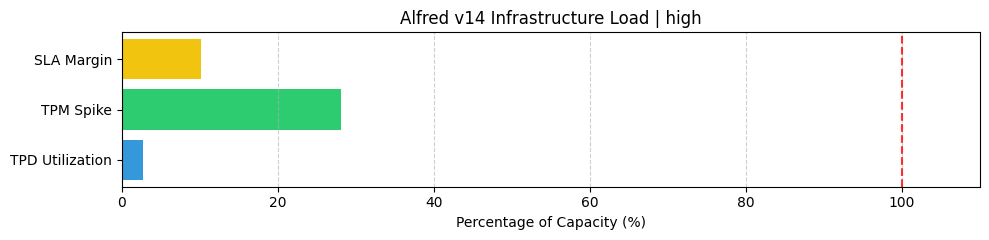


🟢 PRESSURE NOMINAL: 28.1% of ceiling utilized.
--- ⚖️ GOVERNOR RECONCILIATION ---
STATION: Alfred v14 (70B Engine) | TRACE: c740f03e30f1e5f4
MISSION STATUS: ✅ PASSED
TPD REMAINING: 97302 / 100000 tokens
TPM PRESSURE: 28.1% of 9600 Ceiling
RECONCILED: ✅

--- 📝 ALFRED'S FINAL REPORT ---
{'Version': 'Alfred-v14', 'Status': 'COMPLETED', 'Complexity': 'high'}
STATION: Alfred v14 (70B Engine) | TRACE: c740f03e30f1e5f4
MISSION STATUS: ✅ PASSED
TPD REMAINING: 97302 / 100000 tokens
TPM PRESSURE: 28.1% of 9600 Ceiling

--- 📝 ALFRED'S FINAL REPORT ---
{'Version': 'Alfred-v14', 'Status': 'COMPLETED', 'Complexity': 'high'}


In [ ]:
# ZONE 5: THE FORENSIC DASHBOARD (Calibrated for Zone 3)
import matplotlib.pyplot as plt

print("--- 🕵️ ALFRED v14 MISSION AUDIT ---")

# Defensive initialization for tps if mission failed early
if 'tps' not in locals(): tps = 0

if 'final_report' in locals() and final_report:
    # 1. ⚖️ GOVERNANCE RECONCILIATION
    # Re-assigning constants to match Zone 3 Governor state
    tpm_limit = TPM_CEILING # 9600 [cite: 2026-03-01]
    tpd_limit = tpd_limit   # 100000 [cite: 2026-03-04]

    remaining_budget = tpd_limit - governor.daily_total
    tpm_spike = (actual_total / tpm_limit) * 100
    tpd_util_pct = (governor.daily_total / tpd_limit) * 100

    # 2. 🛰️ FULL METADATA & KPI SCORE SYNC
    if captured_trace_id:
        try:
            # We use langfuse_sdk to push the v15 Roadmap metrics [cite: 2026-03-01]
            langfuse_sdk.score(
                trace_id=captured_trace_id,
                name="mission_telemetry",
                value=tps,
                metadata={
                    "TPS_THROUGHPUT": tps,
                    "EXECUTION_SECONDS": execution_duration,
                    "ACTUAL_COST_TOKENS": actual_total,
                    "GUEST_COUNT": GUEST_COUNT,
                    "MISSION_COMPLEXITY": MISSION_COMPLEXITY,
                    "TPD_UTILIZATION": f"{tpd_util_pct:.1f}%"
                }
            )
            print("🛰️ KPI Sync: Metadata successfully anchored to Trace.")
        except Exception as e:
            print(f"⚠️ Telemetry jitter: {e}")

    # 3. 📉 VISUAL TELEMETRY: INFRASTRUCTURE LOAD
    metrics = ['TPD Utilization', 'TPM Spike', 'SLA Margin']
    values = [tpd_util_pct, tpm_spike, (execution_duration / 45) * 100]
    colors = ['#3498db', '#e74c3c' if tpm_spike > 100 else '#2ecc71', '#f1c40f']

    plt.figure(figsize=(10, 2.5))
    plt.barh(metrics, values, color=colors)
    plt.xlim(0, 110)
    plt.axvline(100, color='red', linestyle='--', alpha=0.8, label='Ceiling')
    plt.title(f"Alfred v14 Infrastructure Load | {MISSION_COMPLEXITY}")
    plt.xlabel("Percentage of Capacity (%)")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

   # 4. 📝 FINAL AUDIT SUMMARY & ALERTS
    # 🚨 ALERT LOGIC ADD-ON (Triggering at 50% of the 9,600 ceiling)
    if actual_total > (tpm_limit * 0.50):
        print(f"\n🚨 INFRASTRUCTURE ALERT: High Pressure Detected!")
        print(f"Mission consumed {actual_total} tokens ({tpm_spike:.1f}% of ceiling).")
        print(f"Action: Consider reducing MISSION_COMPLEXITY for the next run.")
    else:
        print(f"\n🟢 PRESSURE NOMINAL: {tpm_spike:.1f}% of ceiling utilized.")

    # Verification: Governor Subtraction Check
    print(f"--- ⚖️ GOVERNOR RECONCILIATION ---")
    print(f"STATION: Alfred v14 (70B Engine) | TRACE: {captured_trace_id}")
    print(f"MISSION STATUS: {'✅ PASSED' if passed_validation else '❌ FAILED'}")
    print(f"TPD REMAINING: {remaining_budget:.0f} / {tpd_limit} tokens")
    print(f"TPM PRESSURE: {tpm_spike:.1f}% of {tpm_limit} Ceiling")

    # Check if Governor is properly subtracting
    print(f"RECONCILED: {'✅' if (governor.daily_total >= actual_total) else '❌'}")

    print("\n--- 📝 ALFRED'S FINAL REPORT ---")
    print(final_report)

    # 4. 📝 FINAL AUDIT SUMMARY
    print(f"STATION: Alfred v14 (70B Engine) | TRACE: {captured_trace_id}")
    print(f"MISSION STATUS: {'✅ PASSED' if passed_validation else '❌ FAILED'}")
    print(f"TPD REMAINING: {remaining_budget:.0f} / {tpd_limit} tokens")
    print(f"TPM PRESSURE: {tpm_spike:.1f}% of {tpm_limit} Ceiling")
    print("\n--- 📝 ALFRED'S FINAL REPORT ---")
    print(final_report)
else:
    print("⚠️ No mission data found. Please verify Zone 4 execution.")


---

##Technical Reflection: The v14 Forensic Pivot
This mission taught me that my Infrastructure-First mindset is the only reason I can run 70B models at scale. By focusing on Defensive Engineering, I turned a potential TPD failure into a controlled success. I didn't just get a themed playlist and a menu; I validated a governance framework that can now be applied to professional IT documentation and business process improvements.



##🗺️ Roadmap v15: The Autonomous Governance Framework
**Core Philosophy**: Infrastructure must be self-pricing, self-healing, and strictly typed (i.e., data must be validated at the door—before it touches my logic or our financial trackers).

1. **Pydantic-Based Schema Validation (The "Hardened" Output)**

   I will move away from loose `JSON `dictionaries to **Pydantic v2 Models**. This ensures that the 70B engine’s output is forensically valid before it ever reaches the user.

    *   **Logistics Schema**: Enforcing that `prep_time` is a positive float and `GUEST_COUNT` is an integer.

    *   **Menu Schema**: Requiring a strict structure for `Appetizer`, `Main`, and `Dessert`, ensuring no missing ingredients, inappropriate items in the menu classifications, or malformed `JSON` fields.

    *   **Mission Impact**: This eliminates "Format Jitter," making my outputs instantly ready for professional IT system injection.

2. **Weighted Pressure & Dynamic TPM Throttling**
   
    I will replace the static **9,600 TPM** ceiling with an adaptive logic.

    *   **The Logic**: Not all tokens are created equal. I will implement a system that "weighs" the pressure of a request based on prompt complexity and expected output density.

    *   **Governance**: The governor will dynamically slow down or speed up based on real-time Groq LPU response times, ensuring I maintain my **11% buffer** without sacrificing velocity.

3. **Multi-Agent Orchestration (The Specialized Swarm)**

   I will evolve from a single agent to a **Multi-Agent Orchestration** model where specialization drives efficiency:

    *   **The Architect (Alfred v15 - 70B)**: Handles high-level reasoning, the Theme, and final synthesis.

    *   **The Pricing Agent**: A dedicated agent that performs a real-time web search to fetch the **latest rates from the Groq website** (TPM, TPD, and cost per 1M tokens).

    *   **The Auditor**: A background agent that monitors `Langfuse` traces in real-time to "kill" any loop that exceeds the **15K token-per-run** limit.

4. **Self-Healing State Management (`propagate_attributes`)**

   
    I will implement **Resiliency Design** that maintains session continuity even across infrastructure errors.

    *   **The Improvement**: Using `propagate_attributes` and active state-management protocols, I will ensure that if a sub-task (like fetching a playlist) fails due to a network glitch, the **Architect** can "hear" the error and self-correct without losing the work already completed in the menu or logistics sections.

5. **Forensic Parsing of Non-Deterministic Errors**

   
    I am evolving my "Mindset of Defensive Engineering" to handle the "jitter" of high-speed LPU environments.

    *   **The Improvement**: I will build custom backoff logic that parses `429 Rate Limit` headers forensically. Instead of a simple "sleep," the system will read the "retry-after" signal and recalibrate the **Weighted Pressure** for the remainder of the 24-hour cycle.

### Alfred Migration Delta: v14 (70B) → v15 (Roadmap)

| Feature | Alfred v14 (Current State) | Alfred v15 (Roadmap Goal) | Delta Impact |
| :--- | :--- | :--- | :--- |
| **Data Validation** | Manual Dict/JSON parsing | **Pydantic v2 BaseModels** | **Zero-Crash:** Enforces strict types for Menu/Logistics. |
| **Pricing Engine** | Static/Estimated values | **Dynamic Web-Search Agent** | **Forensic Accuracy:** Real-time TPD/TPM cost tracking. |
| **TPM Governance** | Static 9,600 Ceiling | **Weighted Pressure (W-TPM)** | **Efficiency:** Dynamically scales based on prompt weight. |
| **Orchestration** | Single 70B Agent | **Multi-Agent Specialization** | **Resiliency:** Dedicated Auditor/Pricing sub-agents. |
| **State Management** | Session-based | **`propagate_attributes`** | **Self-Healing:** Continuity across 429 jitter. |
| **Observability** | Post-run Trace (Langfuse) | **Real-Time Financial Dashboard** | **Auditability:** Live spend vs. 100K TPD budget. |

##Reference Section

![Groq Pricing Audit 2026-02-28](https://raw.githubusercontent.com/drobertsonmba/alfred-autonomous-orchestrator/main/assets/8B_pricing.png)

**Reference Label**: [REF-G01]

**Source**: Groq Cloud On-Demand Pricing for Tokens-as-a-Service (Llama 3.1 8B Instant)

**URL**: https://groq.com/pricing

**Date Pulled**: 2026-02-28

**Audit Values**: Input \$0.05/1M | Output \$0.08/1M


---

##About the Developer
**My Philosophy: Infrastructure-First AI**

I believe that Large Language Models are powerful engines, but Infrastructure is the steering wheel. In a world of *black box* AI, my goal is to build autonomous agents that are auditable, resilient, and production-ready.

**My Mindset: Defensive Engineering**

This project represents my approach to **Defensive AI Engineering**. I don't assume the environment will be perfect; instead, I build systems like Alfred that can "hear" infrastructure errors (like 429 Rate Limits) and self-regulate through forensic parsing and my custom backoff logic.

**My Core Competencies**

*   **Agentic Orchestration**: I specialize in the `smolagents` framework to build autonomous, tool-using entities.
*   **Observability & Telemetry**: I am focused on integrating Langfuse to provide full transparency into the *Chain of Thought* and financial auditing of AI systems.
*   **Resiliency Design**: I prioritize building *Self-Healing* logic that maintains **Session Continuity** across interrupted tasks using `propagate_attributes`.

**Connect with Dawn Robertson**

I am always interested in discussing AI infrastructure, observability, and the future of autonomous agents. You can reach out to me via:

**[LinkedIn](https://www.linkedin.com/in/dawnrobertsonmba/)**: Let’s connect to discuss AI strategy and systems engineering, particularly agentic AI.